In [1]:
library(CellChat)
library(patchwork)
library(Seurat)
library(ggplot2)

pdf_dir <- "cellchat_pdf"
dir.create(pdf_dir, showWarnings = FALSE, recursive = TRUE)

save_pdf_base <- function(filename, width = 8, height = 6, expr) {
  pdf(file.path(pdf_dir, filename), width = width, height = height, onefile = TRUE)
  on.exit(dev.off(), add = TRUE)
  force(expr)
}

save_pdf_gg <- function(plot_obj, filename, width = 8, height = 6) {
  ggplot2::ggsave(
    filename = file.path(pdf_dir, filename),
    plot = plot_obj,
    device = "pdf",
    width = width,
    height = height
  )
}


载入需要的程辑包：dplyr




载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


载入需要的程辑包：igraph


载入程辑包：‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


载入需要的程辑包：ggplot2

Attaching SeuratObject



In [2]:
# 读取结果
cellchat.homing <- readRDS("cellchat_DNhoming_full_results.rds")
cellchat.tumbler <- readRDS("cellchat_DNtumbler_full_results.rds")

In [3]:
# 合并对象
object.list <- list(Homing = cellchat.homing, Tumbler = cellchat.tumbler)
cellchat <- mergeCellChat(object.list, add.names = names(object.list))

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



In [4]:
# 5. 验证是否成功（如果不报错且有输出，才进行下一步）
print(cellchat)

An object of class CellChat created from a merged object with multiple datasets 
 975 signaling genes.
 62601 cells. 
CellChat analysis of single cell RNA-seq data! 


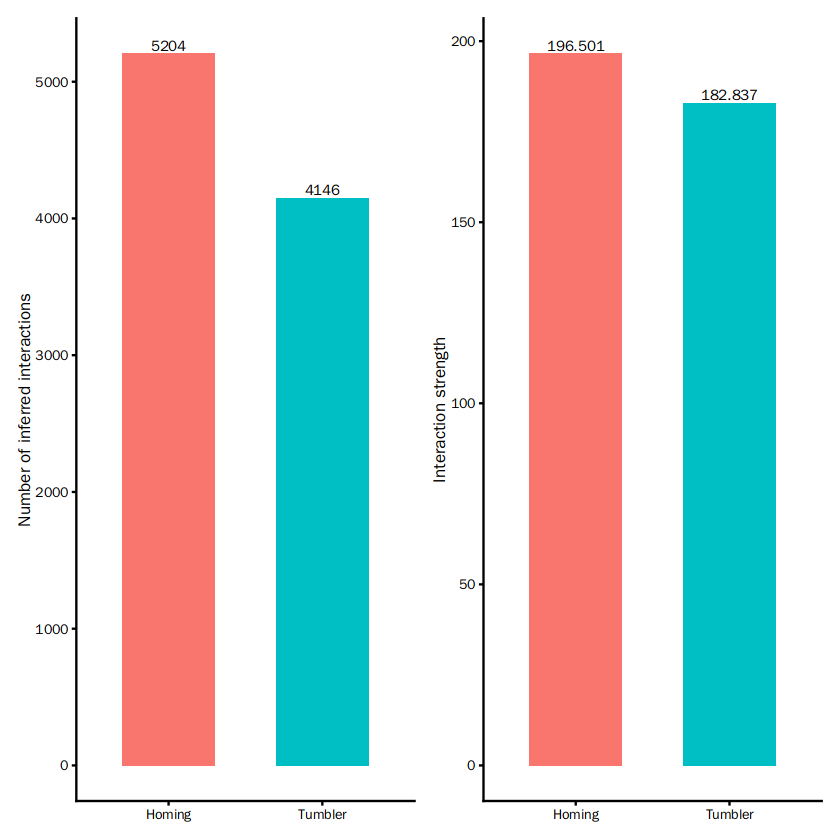

In [5]:
# 作图 1：整体强度对比 (柱状图)
# 看看 Tumbler 的脑区通讯是否比 Homing 更频繁
# 柱状图对比数量和强度
gg1 <- compareInteractions(cellchat, show.legend = FALSE, group = c(1,2))
gg2 <- compareInteractions(cellchat, show.legend = FALSE, group = c(1,2), measure = "weight")
p_combined <- gg1 + gg2
p_combined
save_pdf_gg(p_combined, "01_compareInteractions_number_weight.pdf", width = 12, height = 5)


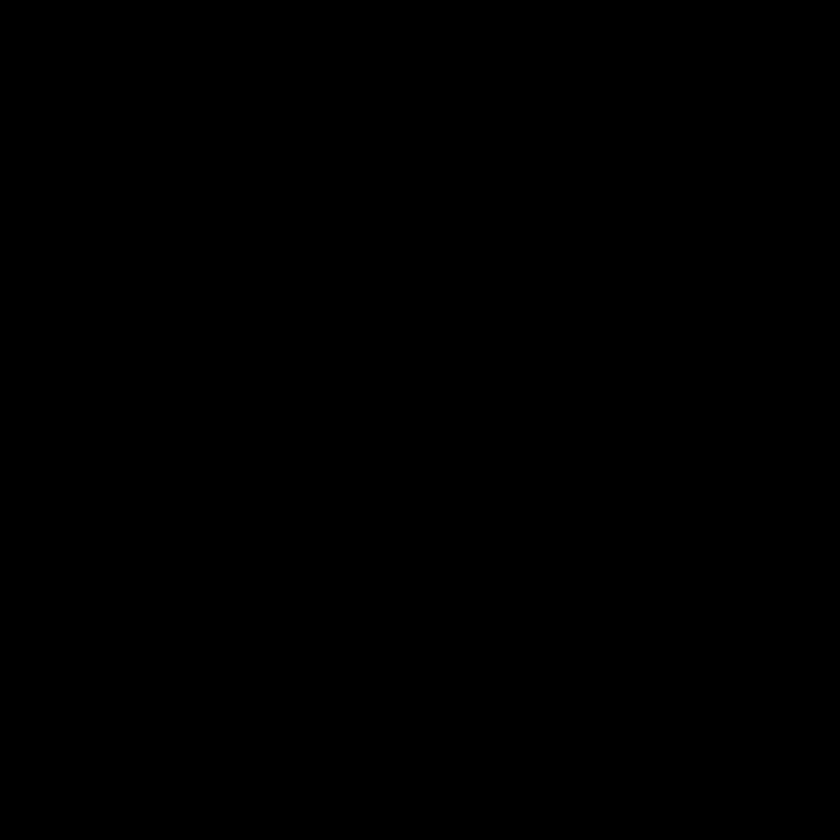

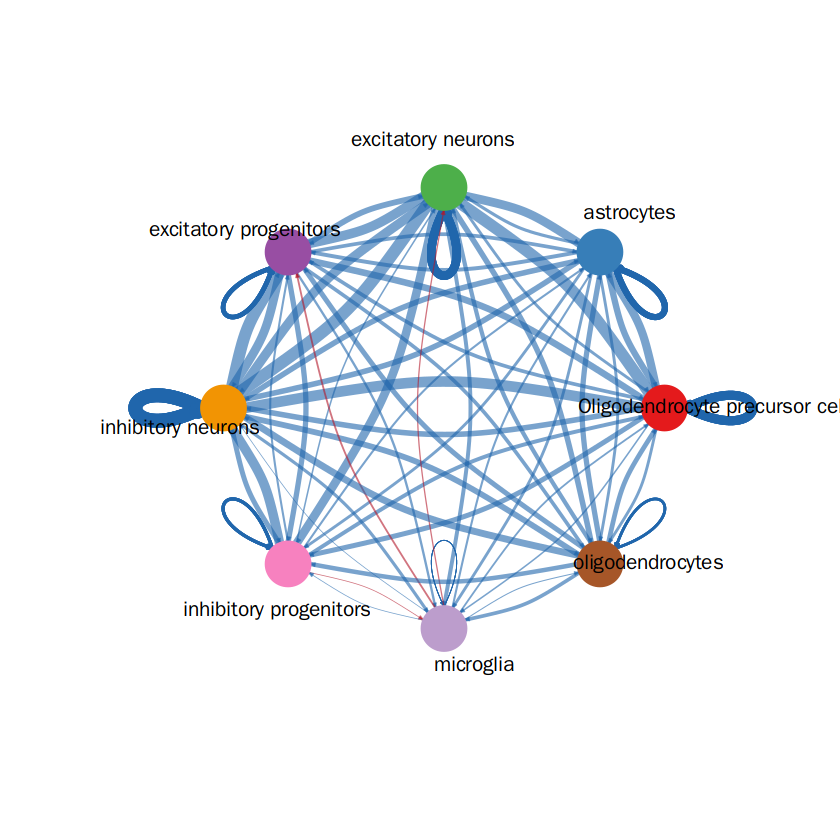

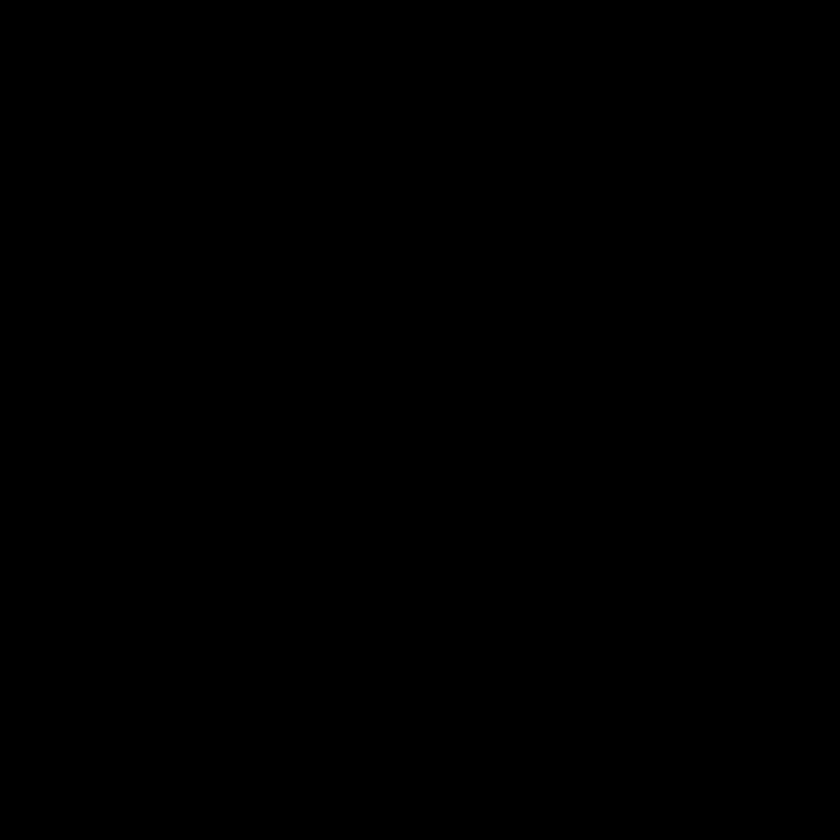

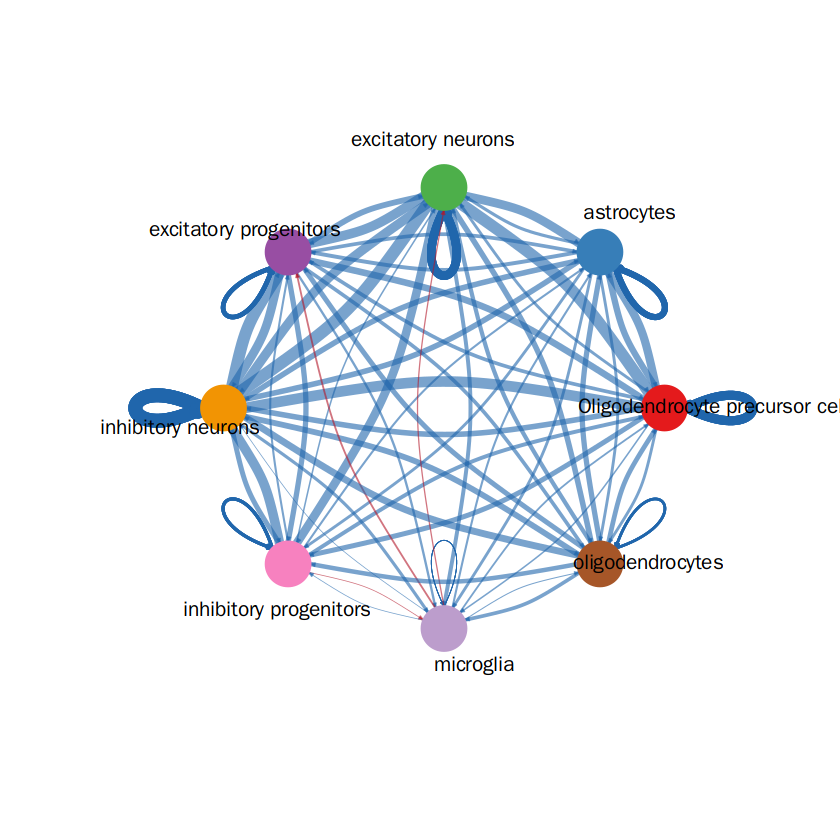

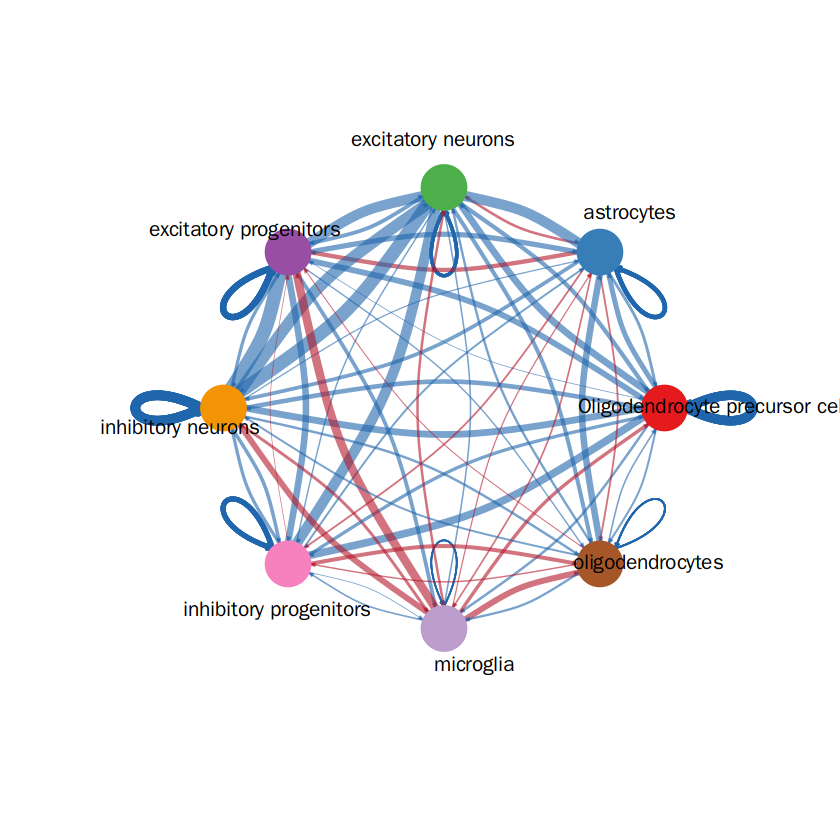

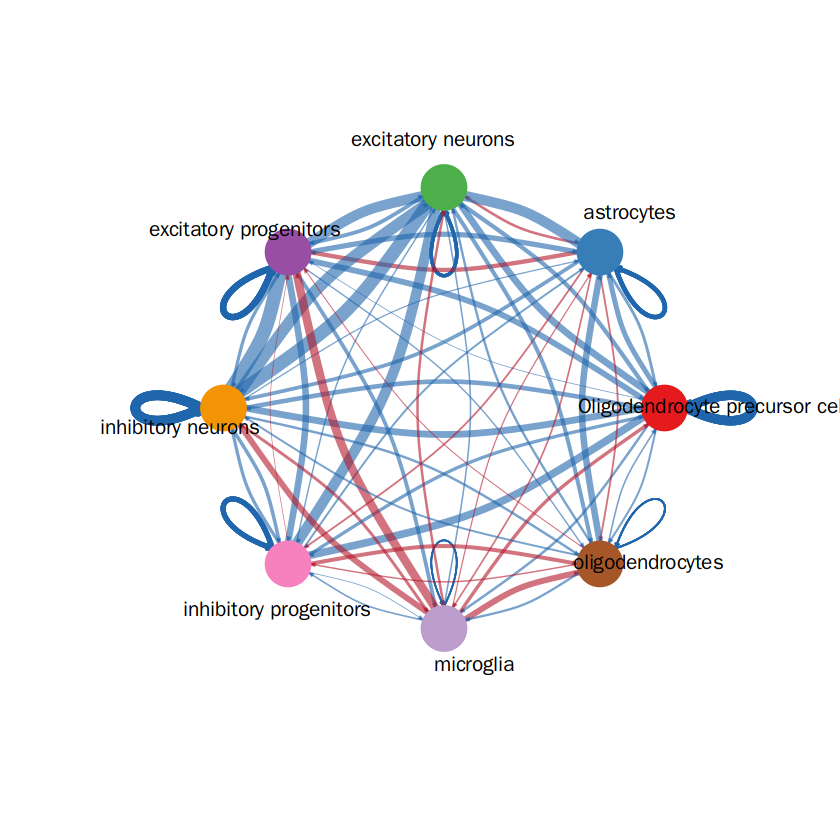

In [6]:
# 作图 2：差分网络图 (核心！)
# 红色线表示在 Tumbler 中增强，蓝色线表示减弱
# 这张图能直接告诉你：翻飞行为是否与特定脑区（如运动神经元）的通讯增强有关
save_pdf_base("02_diffInteraction_number.pdf", width = 8, height = 8, {
  netVisual_diffInteraction(cellchat, weight.scale = TRUE)
})
netVisual_diffInteraction(cellchat, weight.scale = TRUE)

save_pdf_base("03_diffInteraction_weight.pdf", width = 8, height = 8, {
  netVisual_diffInteraction(cellchat, weight.scale = TRUE, measure = "weight")
})
netVisual_diffInteraction(cellchat, weight.scale = TRUE, measure = "weight")


Do heatmap based on a merged object 




Do heatmap based on a merged object 




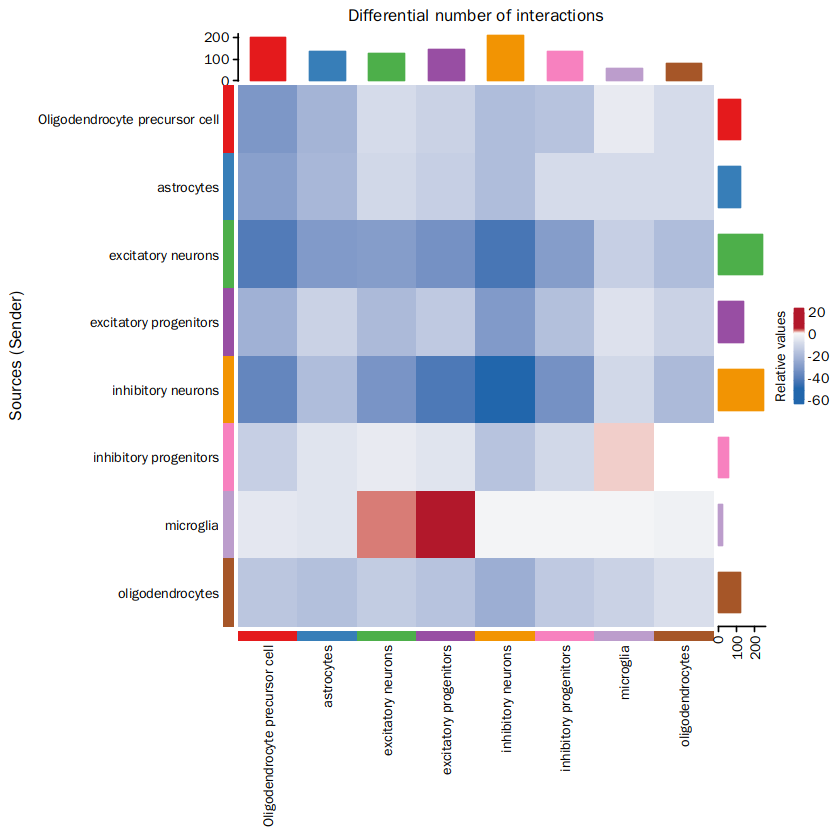

In [7]:
# 还可以使用热图更详细地显示相互作用的不同数量或相互作用强度。
# 顶部的彩色条形图表示热图(incoming signaling)中显示的列值之和。
# 右边的彩色条形图表示值行之和(outcoming signaling。
save_pdf_base("04_heatmap_number.pdf", width = 8, height = 6, {
  netVisual_heatmap(cellchat)
})
netVisual_heatmap(cellchat)


Do heatmap based on a merged object 


Do heatmap based on a merged object 




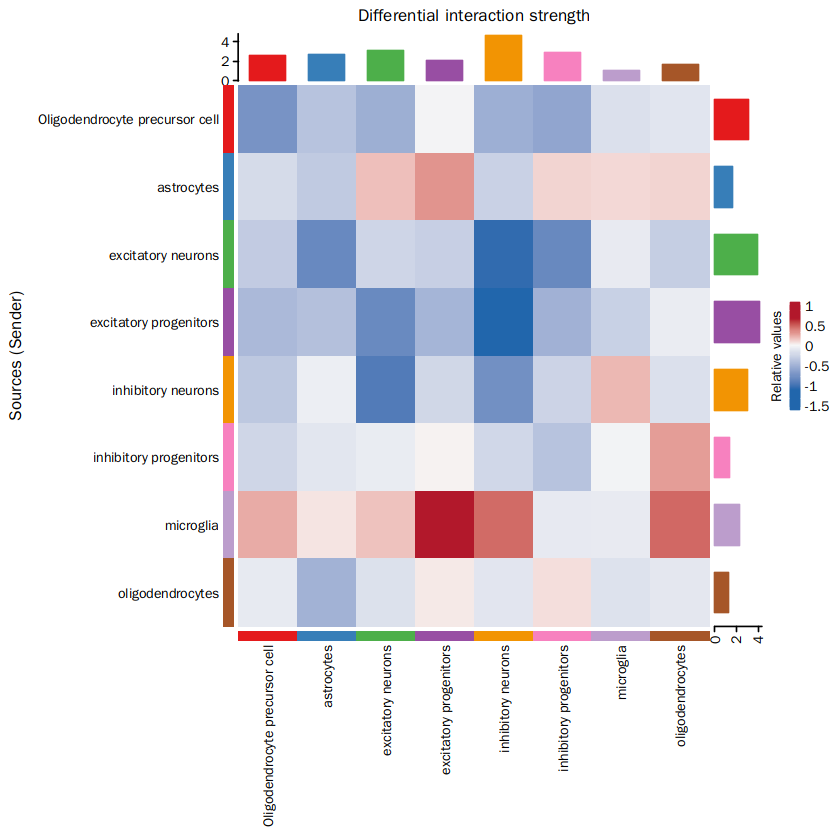

In [8]:
save_pdf_base("05_heatmap_weight.pdf", width = 8, height = 6, {
  netVisual_heatmap(cellchat, measure = "weight")
})
netVisual_heatmap(cellchat, measure = "weight")


Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways



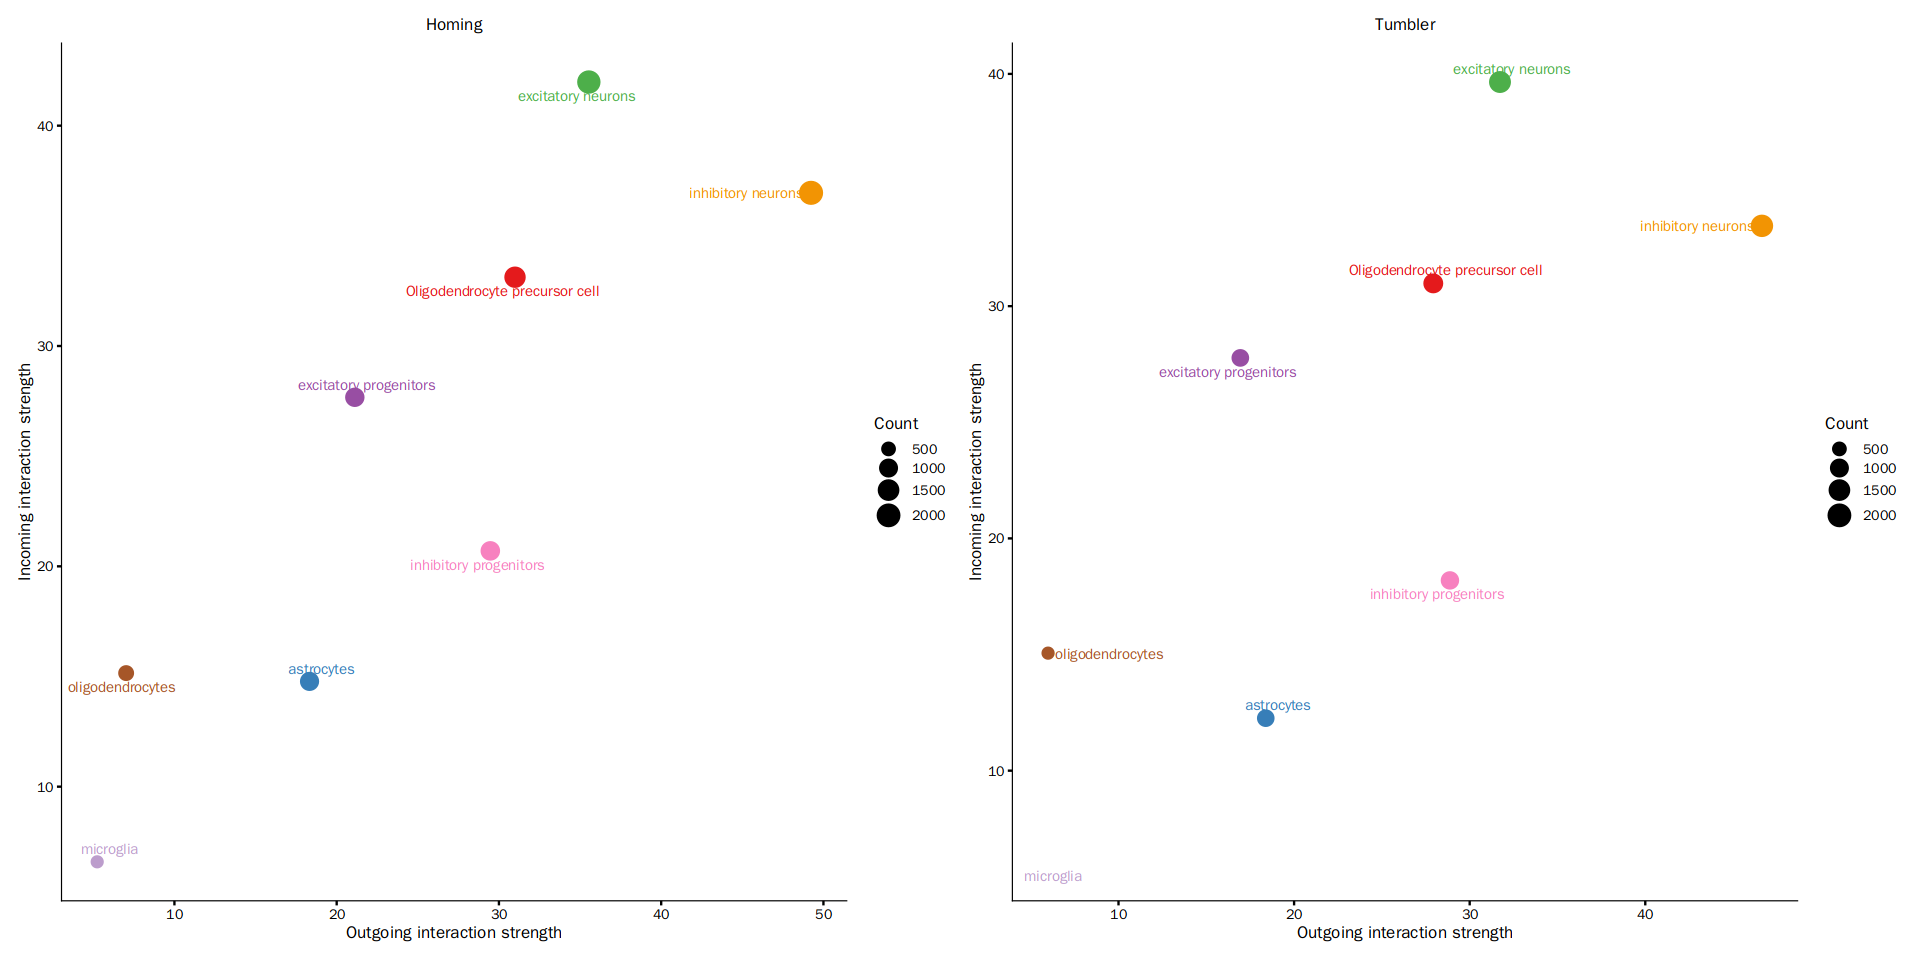

In [9]:
options(repr.plot.width = 16, repr.plot.height = 8)
# 1. 分别为两个对象计算网络中心度（这一步必不可少）
object.list[[1]] <- netAnalysis_computeCentrality(object.list[[1]], slot.name = "netP")
object.list[[2]] <- netAnalysis_computeCentrality(object.list[[2]], slot.name = "netP")

# 2. 重新计算坐标轴范围（确保两张图的比例尺一致，方便对比）
num.link <- sapply(object.list, function(x) {rowSums(x@net$count) + colSums(x@net$count)})
weight.MinMax <- c(min(num.link), max(num.link))

# 3. 绘制散点图
gg1 <- netAnalysis_signalingRole_scatter(object.list[[1]], title = names(object.list)[1], weight.MinMax = weight.MinMax)
gg2 <- netAnalysis_signalingRole_scatter(object.list[[2]], title = names(object.list)[2], weight.MinMax = weight.MinMax)

# 合并显示
p_scatter <- gg1 + gg2
p_scatter
save_pdf_gg(p_scatter, "06_signalingRole_scatter_two_groups.pdf", width = 14, height = 7)


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler



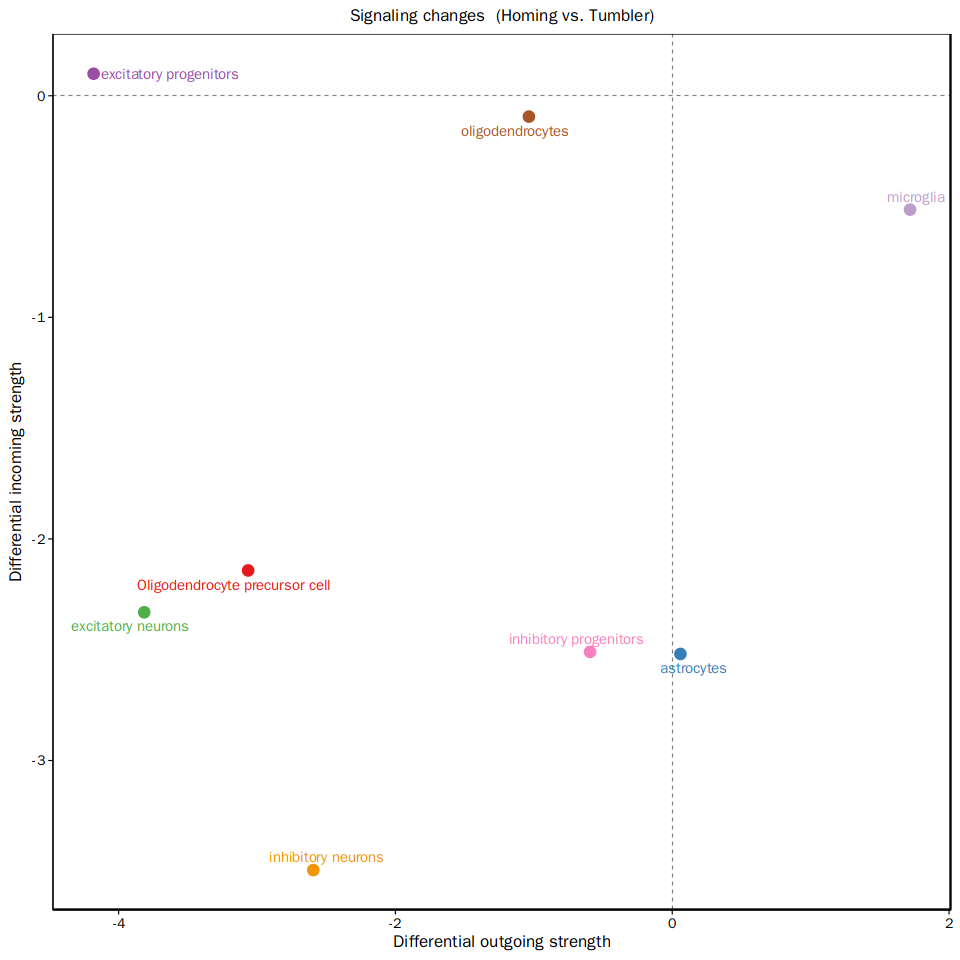

In [10]:
# 再 merge
cellchat <- mergeCellChat(object.list, add.names = names(object.list))

options(repr.plot.width = 8, repr.plot.height = 8)
# 画“差异 sender/receiver”散点
gg.diff <- netAnalysis_diff_signalingRole_scatter(
  cellchat,
  comparison = c(1, 2),   # 1=Homing, 2=Tumbler
  x.measure = "outdeg",
  y.measure = "indeg",
  xlabel = "Differential outgoing strength",
  ylabel = "Differential incoming strength",
  title = "Homing vs Tumbler: signaling role changes"
)

gg.diff
save_pdf_gg(gg.diff, "07_diff_signalingRole_scatter.pdf", width = 8, height = 8)


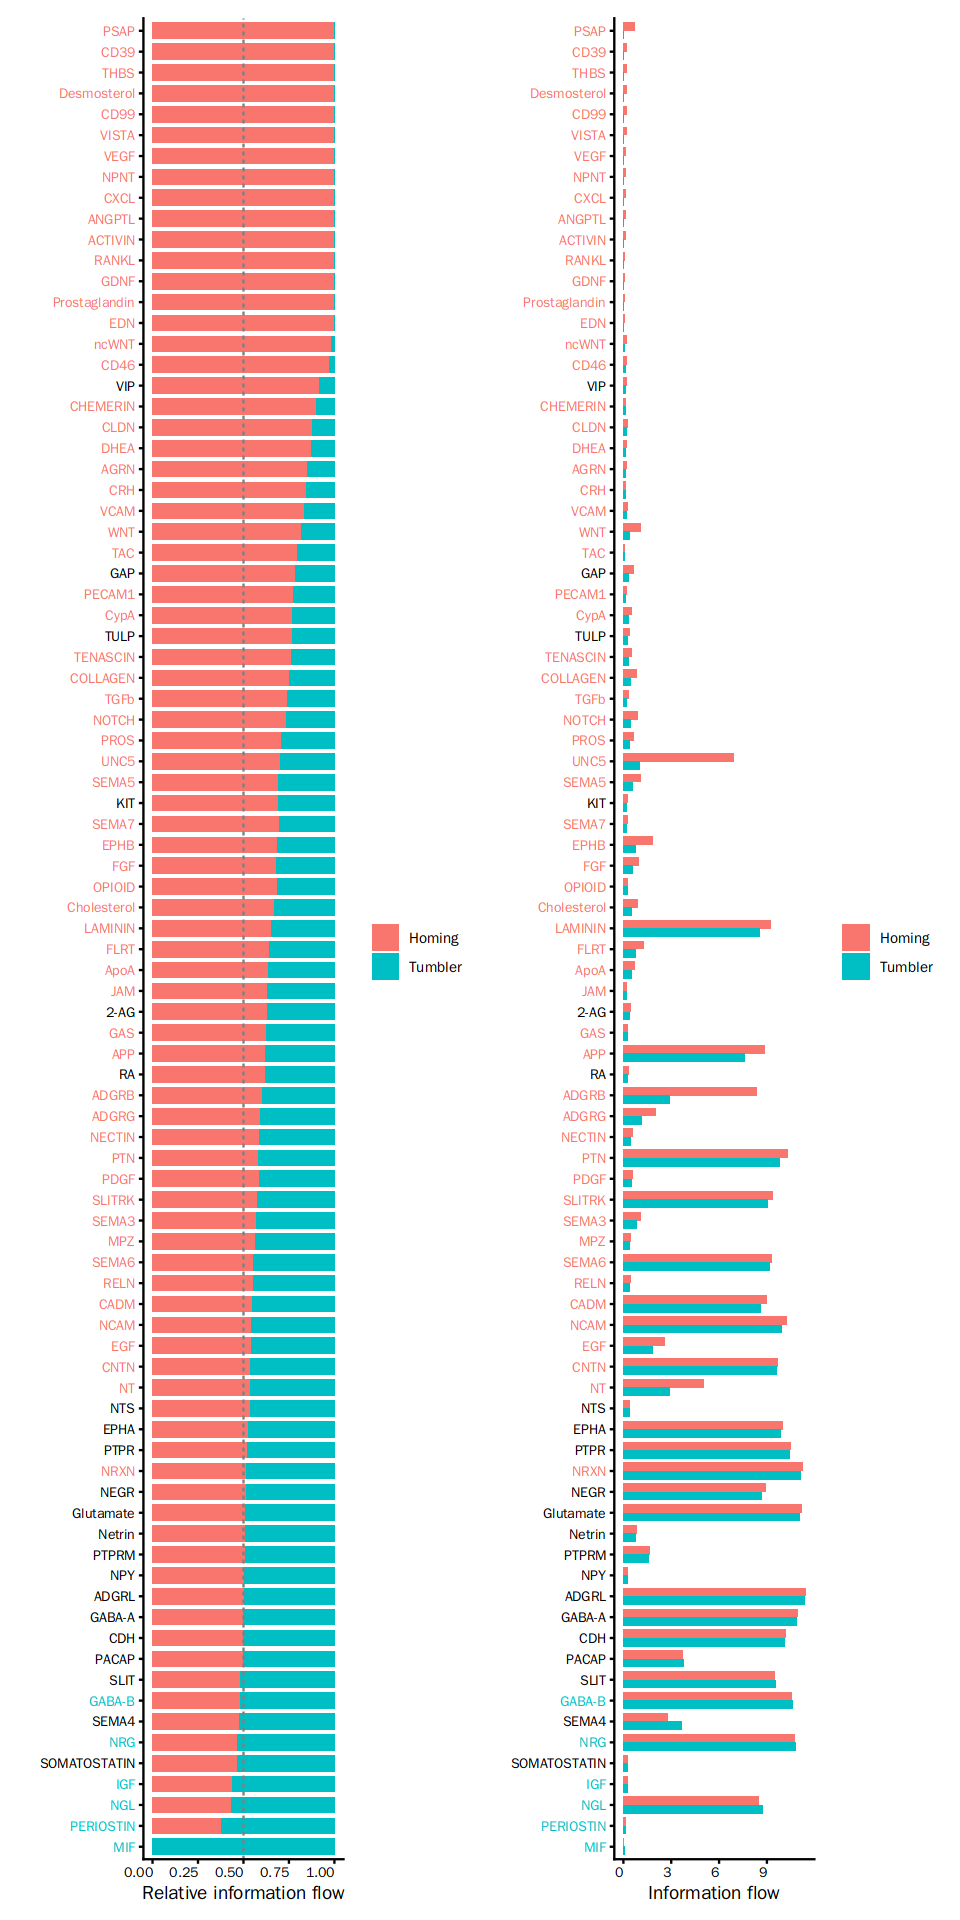

In [11]:
options(repr.plot.width = 8, repr.plot.height = 16)
# 识别在某一群体中特异性上调的通路
gg1 <- rankNet(cellchat, mode = "comparison", stacked = TRUE, do.stat = TRUE)
gg2 <- rankNet(cellchat, mode = "comparison", stacked = FALSE, do.stat = TRUE)
p_rank <- gg1 + gg2
p_rank
save_pdf_gg(p_rank, "08_rankNet_comparison_stacked_and_unstacked.pdf", width = 12, height = 14)


$signaling.contribution
                        name contribution contribution.scaled   group
MIF                      MIF 0.000000e+00          0.00000000  Homing
PERIOSTIN          PERIOSTIN 6.231937e-05          0.10327124  Homing
NGL                      NGL 1.075538e+00          8.44189383  Homing
IGF                      IGF 1.590392e-02          0.24147650  Homing
SOMATOSTATIN    SOMATOSTATIN 1.438307e-02          0.23575436  Homing
NRG                      NRG 1.080913e+01         10.70346354  Homing
SEMA4                  SEMA4 6.992281e-01          2.79502761  Homing
GABA-B                GABA-B 8.735407e+00         10.54749321  Homing
SLIT                    SLIT 2.751385e+00          9.45570094  Homing
PACAP                  PACAP 7.621929e-01          3.68248679  Homing
CDH                      CDH 5.080906e+00         10.15756740  Homing
GABA-A                GABA-A 2.433708e+01         10.93741902  Homing
ADGRL                  ADGRL 3.175908e+01         11.40533000  Hom

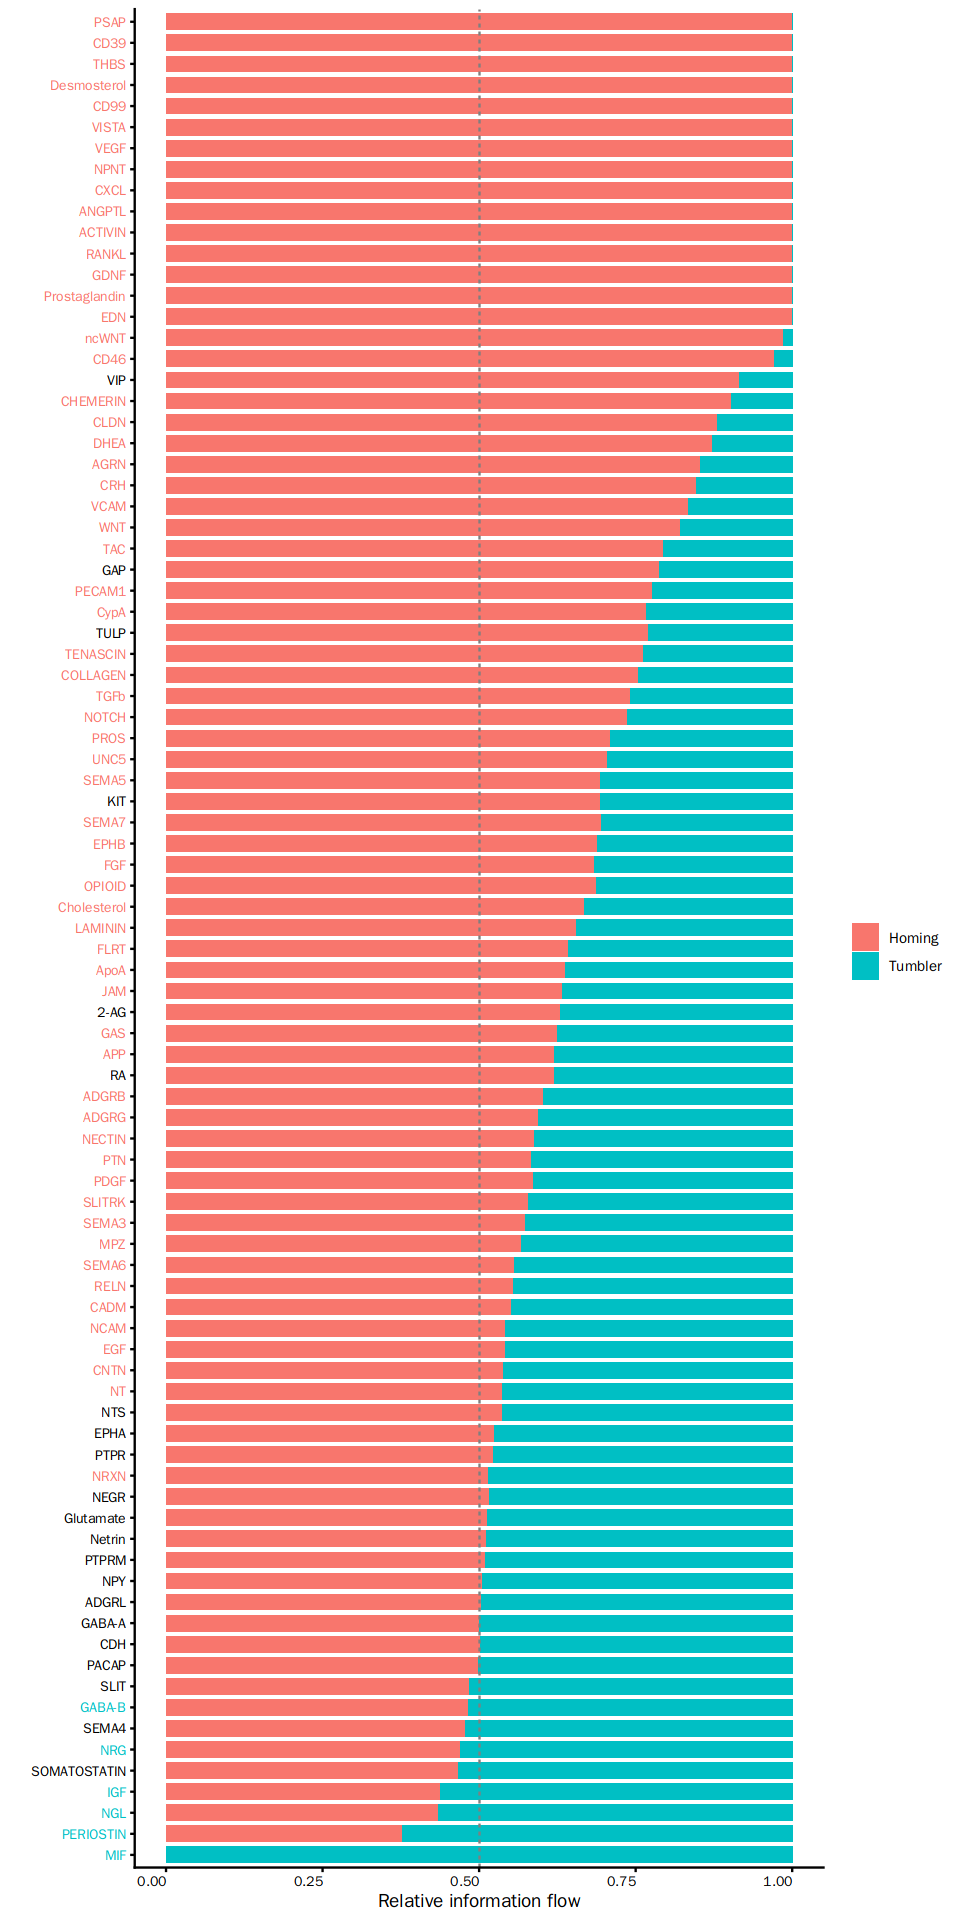

In [12]:
net_data_list <- rankNet(cellchat, 
                         mode = "comparison", 
                         stacked = T, 
                         do.stat = TRUE, 
                         return.data = TRUE)
net_data_list


载入程辑包：‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing




[1] "差异最显著的前 20 个通路："
 [1] NRXN     PTN      NRG      LAMININ  NCAM     SLITRK   GABA-B   APP     
 [9] SEMA6    CNTN     UNC5     ADGRB    NGL      EPHB     WNT      CADM    
[17] PSAP     SEMA5    NOTCH    COLLAGEN
88 Levels: MIF PERIOSTIN NGL IGF SOMATOSTATIN NRG SEMA4 GABA-B SLIT ... PSAP


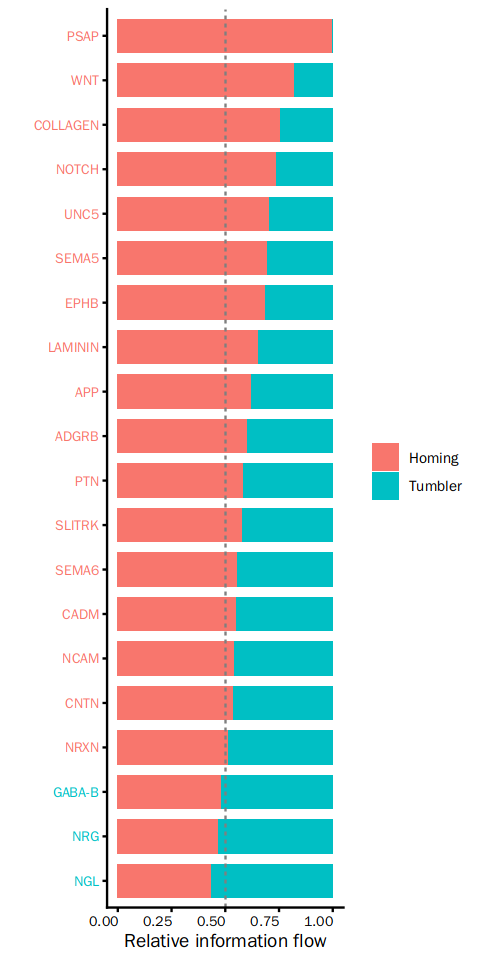

In [13]:
options(repr.plot.width = 4, repr.plot.height = 8)
library(dplyr)
library(tidyr)

# 1. 提取数据
df.net <- net_data_list$signaling.contribution

# 2. 计算两组间的差异并筛选 Top 20
top20_diff_pathways <- df.net %>%
  filter(!is.na(pvalues) & pvalues < 0.05) %>%
  group_by(name) %>%
  summarize(
    Homing_contrib = sum(contribution[group == "Homing"], na.rm = TRUE),
    Tumbler_contrib = sum(contribution[group == "Tumbler"], na.rm = TRUE),
    diff = abs(Homing_contrib - Tumbler_contrib)
  ) %>%
  arrange(desc(diff)) %>%
  slice_head(n = 20) %>%
  pull(name)

# 3. 验证结果
print("差异最显著的前 20 个通路：")
print(top20_diff_pathways)

# 4. 可视化
p_top20 <- rankNet(cellchat, 
        mode = "comparison", 
        stacked = TRUE, 
        signaling = top20_diff_pathways)
p_top20
save_pdf_gg(p_top20, "09_rankNet_top20_diff_pathways.pdf", width = 5, height = 8)


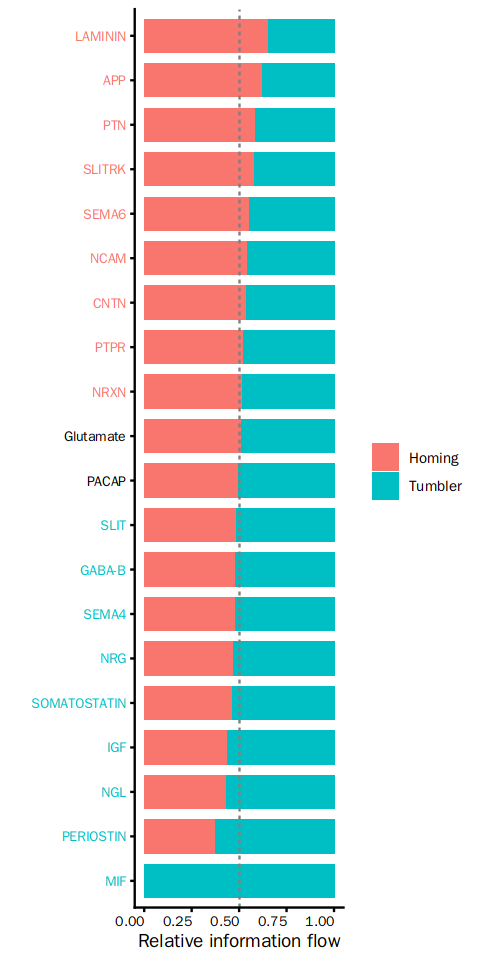

In [14]:
# 在 Tumbler 中显著增强的 Top 10
top10_up <- df.net %>%
  group_by(name) %>%
  summarize(diff = sum(contribution[group == "Tumbler"]) - sum(contribution[group == "Homing"])) %>%
  arrange(desc(diff)) %>% slice_head(n = 10) %>% pull(name)

# 在 Homing 中显著增强的 Top 10
top10_down <- df.net %>%
  group_by(name) %>%
  summarize(diff = sum(contribution[group == "Homing"]) - sum(contribution[group == "Tumbler"])) %>%
  arrange(desc(diff)) %>% slice_head(n = 10) %>% pull(name)

# 合并展示
top20_combined <- c(top10_up, top10_down)

p_top20_ud <- rankNet(cellchat, 
        mode = "comparison", 
        stacked = TRUE, 
        signaling = top20_combined)
p_top20_ud
save_pdf_gg(p_top20_ud, "10_rankNet_top10_up_top10_down.pdf", width = 5, height = 8)


In [15]:
# 共有通路
common_pathways <- intersect(object.list[[1]]@netP$pathways, object.list[[2]]@netP$pathways)
# Tumbler 特有通路
tumbler_only <- setdiff(object.list[[2]]@netP$pathways, object.list[[1]]@netP$pathways)
homing_only <- setdiff(object.list[[1]]@netP$pathways, object.list[[2]]@netP$pathways)

print(paste("共有通路数量:", length(common_pathways)))
print(paste("Tumbler特有通路:", paste(tumbler_only, collapse = ", ")))
print(paste("Homing 特有通路清单:", paste(homing_only, collapse = ", ")))

# 3. 汇总对比 (可选：整理成一个列表方便后续循环作图)
pathway_comparison <- list(
  Common = common_pathways,
  Tumbler_Specific = tumbler_only,
  Homing_Specific = homing_only
)

[1] "共有通路数量: 72"
[1] "Tumbler特有通路: MIF"
[1] "Homing 特有通路清单: PSAP, CD39, THBS, Desmosterol, CD99, VISTA, VEGF, NPNT, CXCL, ANGPTL, ACTIVIN, RANKL, GDNF, Prostaglandin, EDN"


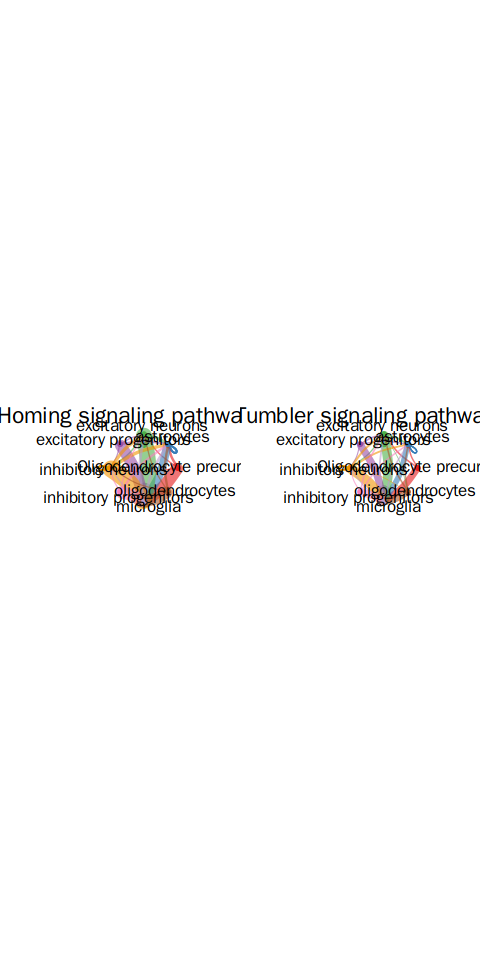

In [16]:
pathways.show <- c("APP") # 替换为你感兴趣的通路

# 比较特定通路在两组中的层级图
weight.max <- getMaxWeight(object.list, slot.name = c("netP"), attribute = pathways.show)
save_pdf_base("11_pathway_APP_circle_comparison.pdf", width = 12, height = 6, {
  par(mfrow = c(1,2), xpd = TRUE)
  for (i in 1:length(object.list)) {
    netVisual_aggregate(object.list[[i]], signaling = pathways.show, layout = "circle", 
                        edge.weight.max = weight.max[1], edge.width.max = 10, 
                        signaling.name = paste(pathways.show, names(object.list)[i]))
  }
})
par(mfrow = c(1,2), xpd = TRUE)
for (i in 1:length(object.list)) {
  netVisual_aggregate(object.list[[i]], signaling = pathways.show, layout = "circle", 
                      edge.weight.max = weight.max[1], edge.width.max = 10, 
                      signaling.name = paste(pathways.show, names(object.list)[i]))
}


In [17]:
# 1. 定义你想要查看的多个通路
# 你可以使用之前筛选出的 common_pathways，或者手动指定
#pathways.show.all <- c("GDNF", "BDNF", "WNT", "NOTCH", "GLUTAMATE") 
pathways.show.all <- common_pathways

# 2. 打开 PDF 设备，设置页面大小
pdf("Pigeon_XN_Multi_Pathways_Comparison.pdf", width = 12, height = 6)

for (i in 1:length(pathways.show.all)) {
  pathway.now <- pathways.show.all[i]
  
  # 检查该通路是否在两组中都存在
  # 如果只在单组存在，getMaxWeight 会报错，所以这里做一个判断
  present_in <- sapply(object.list, function(x) pathway.now %in% x@netP$pathways)
  
  if (all(present_in)) {
    # 计算两组间的最大权重，保证连线粗细的可比性
    weight.max <- getMaxWeight(object.list, slot.name = c("netP"), attribute = pathway.now)
    
    # 设置绘图布局：1行2列
    par(mfrow = c(1,2), xpd = TRUE)
    
    for (j in 1:length(object.list)) {
      netVisual_aggregate(object.list[[j]], 
                          signaling = pathway.now, 
                          layout = "circle", 
                          edge.weight.max = weight.max[1], 
                          edge.width.max = 10, 
                          signaling.name = paste(pathway.now, names(object.list)[j]))
    }
  } else if (any(present_in)) {
    # 如果该通路只在其中一组中存在（特有通路）
    par(mfrow = c(1,2), xpd = TRUE)
    for (j in 1:length(object.list)) {
      if (present_in[j]) {
        netVisual_aggregate(object.list[[j]], signaling = pathway.now, layout = "circle", 
                            signaling.name = paste(pathway.now, names(object.list)[j], "(Specific)"))
      } else {
        plot.new()
        text(0.5, 0.5, paste(pathway.now, "\n在", names(object.list)[j], "\n中未检测到"), cex = 1.2)
      }
    }
  }
}

dev.off() # 关闭 PDF

pdf 
  2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler



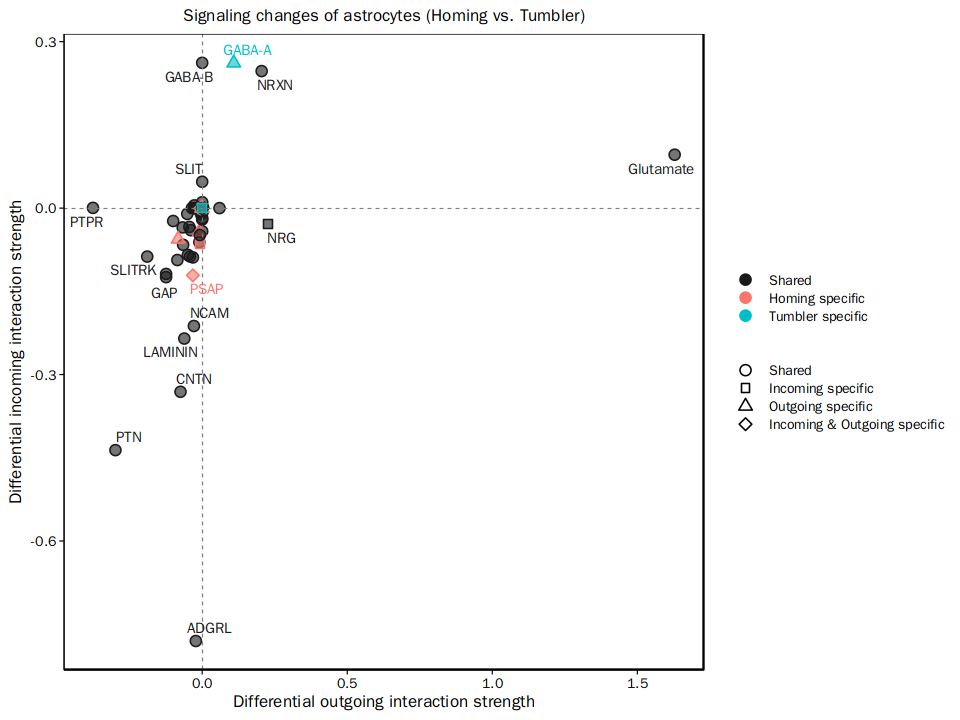

In [18]:
options(repr.plot.width = 8, repr.plot.height = 6)
# 比较保守和特异性的信号通路
# 这一步会告诉你哪些通路是两组共有的，哪些是 Tumbler 特有的
# 1. 分别为两个原始对象计算中心度（必须步骤）
object.list[[1]] <- netAnalysis_computeCentrality(object.list[[1]], slot.name = "netP")
object.list[[2]] <- netAnalysis_computeCentrality(object.list[[2]], slot.name = "netP")

# 2. 重新合并对象
cellchat <- mergeCellChat(object.list, add.names = names(object.list))

# 3. 现在执行针对 granular cells 的散点图
# 请确保 "astrocytes" 的拼写与实际 cell type 完全一致
ht1 <- netAnalysis_signalingChanges_scatter(cellchat, idents.use = "astrocytes")
ht1
save_pdf_gg(ht1, "13_signalingChanges_scatter_astrocytes.pdf", width = 8, height = 6)


In [19]:

# --- 第二步：确保元数据格式纯净 ---
all_idents <- levels(cellchat@meta$cell_type)
all_idents

# --- 第三步：重新尝试绘图 ---
pdf("signaling_difference_cellType.pdf", width = 12, height = 9)

for (current_type in all_idents) {
  message(paste0("Testing: ", current_type))
  
  # 使用 tryCatch 捕获函数内部的 $ 错误
  try({
    p <- netAnalysis_signalingChanges_scatter(cellchat, idents.use = current_type)
    p <- p + ggplot2::ggtitle(paste("Signaling Changes:", current_type))
    print(p)
  }, silent = FALSE)
}

dev.off()

[1] "Oligodendrocyte precursor cell" "astrocytes"                    
[3] "excitatory neurons"             "excitatory progenitors"        
[5] "inhibitory neurons"             "inhibitory progenitors"        
[7] "microglia"                      "oligodendrocytes"

Testing: Oligodendrocyte precursor cell

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler

The following `from` values were not present in `x`: 1



Testing: astrocytes

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler

Testing: excitatory neurons

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler

Testing: excitatory progenitors

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler

Testing: inhibitory neurons

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler

Testing: inhibitory progenitors

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler

The following `from` values were not present in `x`: 2

Testing: microglia

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler

Testing: oligodendrocytes

Visualizing differential outgoing and incoming signaling changes from Homing to Tumbler



pdf 
  2

载入需要的程辑包：grid

ComplexHeatmap version 2.14.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




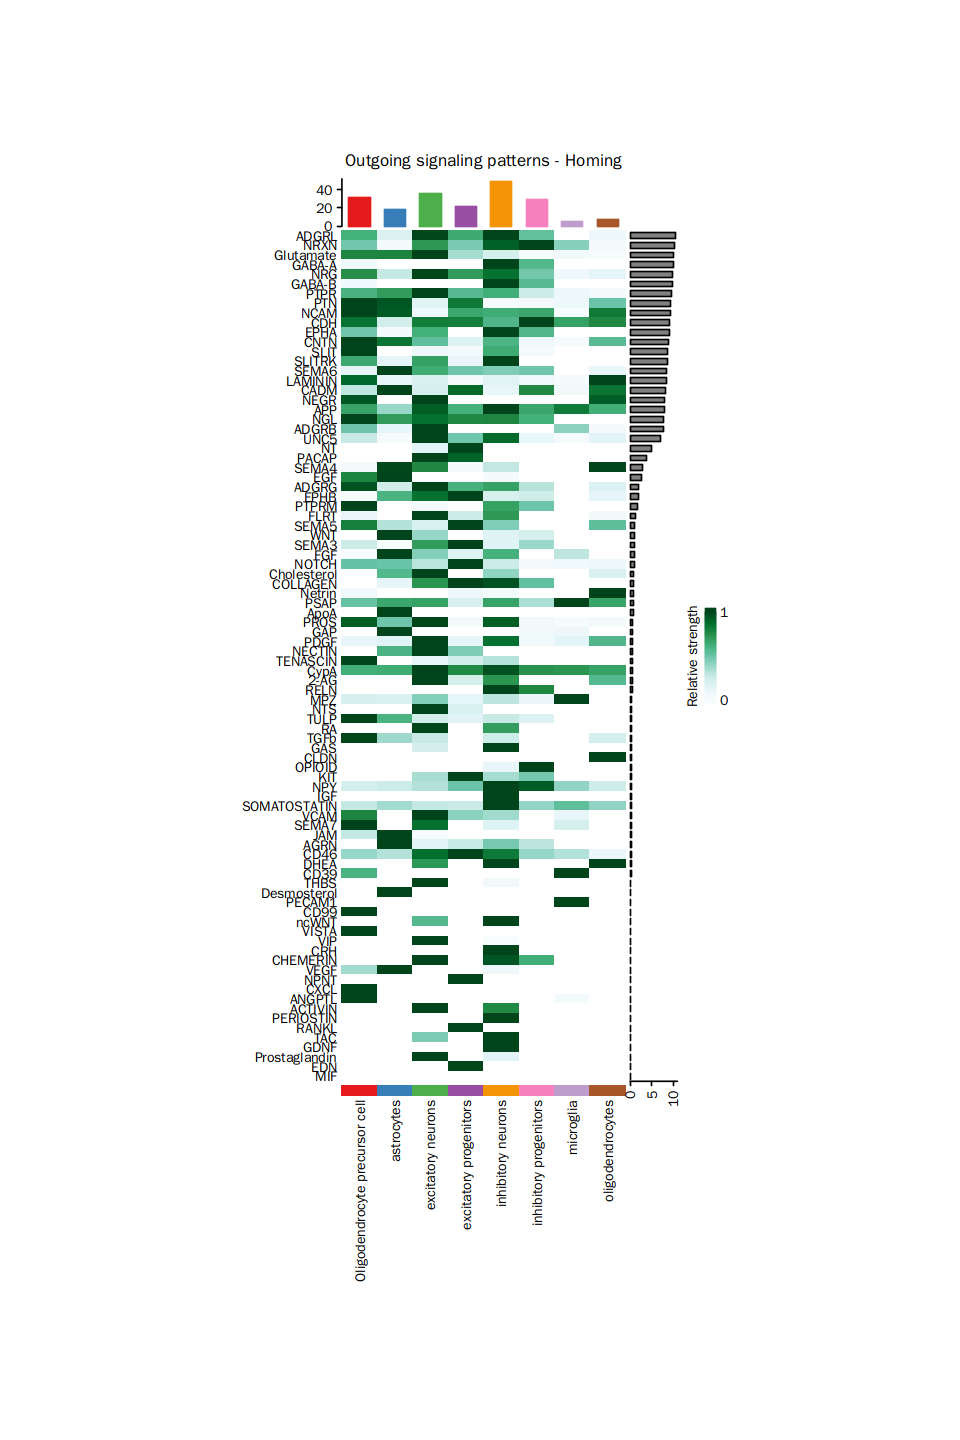

In [20]:
options(repr.plot.width = 8, repr.plot.height = 12)
# 作图 3：信号模式对比 (Heatmap)
# 比较与每个细胞群相关的传出(或传入)信号
library(ComplexHeatmap)

i = 1
# combining all the identified signaling pathways from different datasets 
pathway.union <- union(object.list[[i]]@netP$pathways, object.list[[i+1]]@netP$pathways)
ht1 = netAnalysis_signalingRole_heatmap(object.list[[i]], pattern = "outgoing", signaling = pathway.union, title = names(object.list)[i], width = 6, height = 18)
ht2 = netAnalysis_signalingRole_heatmap(object.list[[i+1]], pattern = "outgoing", signaling = pathway.union, title = names(object.list)[i+1], width = 6, height = 18)

save_pdf_base("14_signalingRole_heatmap_Homing.pdf", width = 8, height = 12, {
  ComplexHeatmap::draw(ht1)
})
save_pdf_base("15_signalingRole_heatmap_Tumbler.pdf", width = 8, height = 12, {
  ComplexHeatmap::draw(ht2)
})
ht1


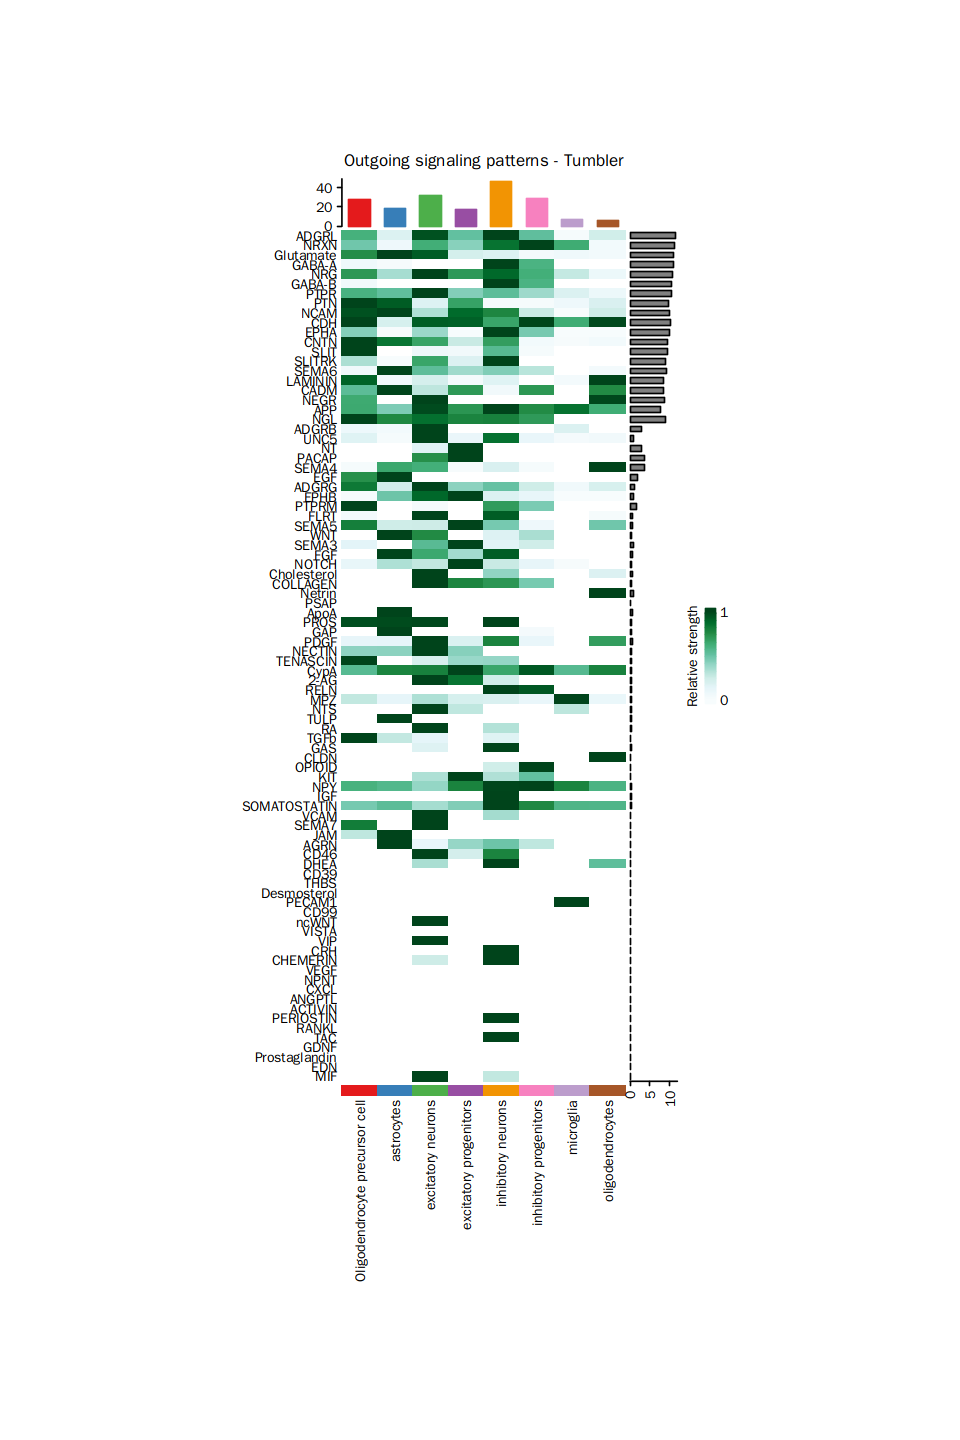

In [21]:
ht2


In [22]:
print(pathway.union)

 [1] "ADGRL"         "NRXN"          "Glutamate"     "GABA-A"       
 [5] "NRG"           "GABA-B"        "PTPR"          "PTN"          
 [9] "NCAM"          "CDH"           "EPHA"          "CNTN"         
[13] "SLIT"          "SLITRK"        "SEMA6"         "LAMININ"      
[17] "CADM"          "NEGR"          "APP"           "NGL"          
[21] "ADGRB"         "UNC5"          "NT"            "PACAP"        
[25] "SEMA4"         "EGF"           "ADGRG"         "EPHB"         
[29] "PTPRM"         "FLRT"          "SEMA5"         "WNT"          
[33] "SEMA3"         "FGF"           "NOTCH"         "Cholesterol"  
[37] "COLLAGEN"      "Netrin"        "PSAP"          "ApoA"         
[41] "PROS"          "GAP"           "PDGF"          "NECTIN"       
[45] "TENASCIN"      "CypA"          "2-AG"          "RELN"         
[49] "MPZ"           "NTS"           "TULP"          "RA"           
[53] "TGFb"          "GAS"           "CLDN"          "OPIOID"       
[57] "KIT"           "NPY"        

Comparing communications on a merged object 




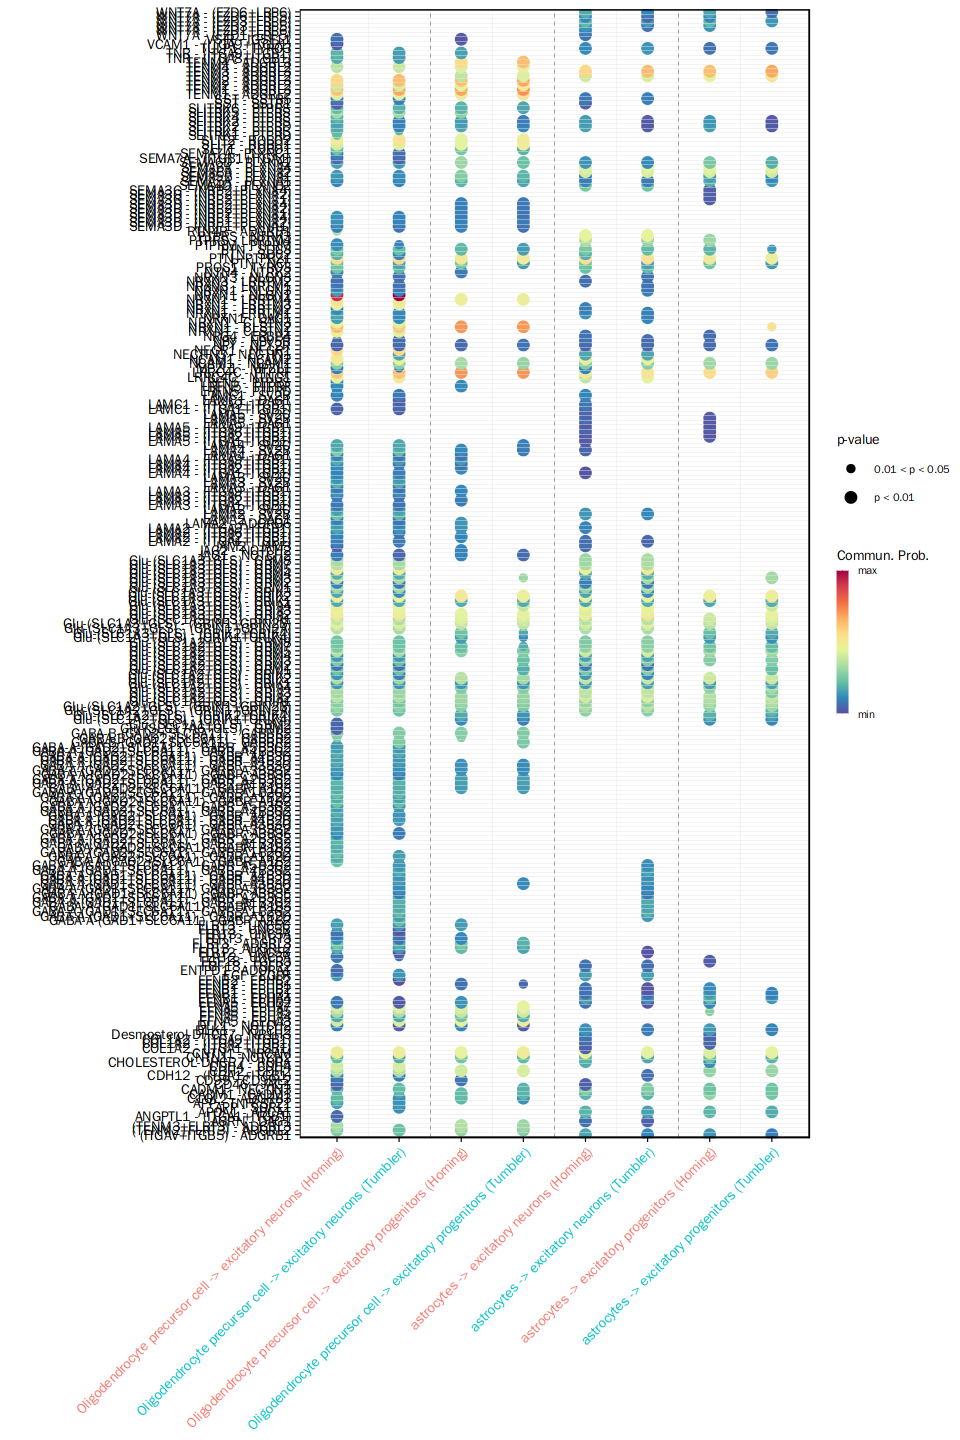

In [23]:
p_bubble <- netVisual_bubble(cellchat,
                 sources.use = c(1,2),
                 targets.use = c(3,4),
                 comparison = c(1,2),
                 angle.x = 45)
p_bubble
save_pdf_gg(p_bubble, "16_bubble_sources12_targets34.pdf", width = 9, height = 7)
